In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import prophet as Prophet
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Amazon Sale Report.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Cloud Warehouse Compersion Chart.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/May-2022.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/P  L March 2021.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/International sale Report.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Expense IIGF.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Sale Report.csv


In [47]:
import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

In [78]:
data = pd.read_csv("/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Amazon Sale Report.csv", 
                   dtype={23: str, 22: str}) 

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [82]:
data["Date"] = pd.to_datetime(data["Date"], format="%m-%d-%y")

In [83]:
drops=['index', 'Order ID', 'ASIN', 'SKU', 'Unnamed: 22', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'currency', 'fulfilled-by', 'Courier Status']
data.drop(columns=drops, axis=1, inplace=True)

In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                128975 non-null  datetime64[ns]
 1   Status              128975 non-null  object        
 2   Fulfilment          128975 non-null  object        
 3   Sales Channel       128975 non-null  object        
 4   ship-service-level  128975 non-null  object        
 5   Style               128975 non-null  object        
 6   Category            128975 non-null  object        
 7   Size                128975 non-null  object        
 8   Qty                 128975 non-null  int64         
 9   Amount              121180 non-null  float64       
 10  promotion-ids       79822 non-null   object        
 11  B2B                 128975 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1), object(8)
memory usage: 10.9+ MB


In [85]:
data.isnull().sum()

Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
Category                  0
Size                      0
Qty                       0
Amount                 7795
promotion-ids         49153
B2B                       0
dtype: int64

In [86]:
data.head()

,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,Category,Size,Qty,Amount,promotion-ids,B2B
0,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,Set,S,0,647.62,NaN,False
1,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,kurta,3XL,1,406.00,Amazon PLCC Free-Financing Universal Merchant ...,False
2,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,kurta,XL,1,329.00,IN Core Free Shipping 2015/04/08 23-48-5-108,True
3,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,Western Dress,L,0,753.33,NaN,False
4,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,Top,3XL,1,574.00,NaN,False


In [87]:
data["Fulfilment"].unique()

array(['Merchant', 'Amazon'], dtype=object)

In [88]:
data["Status"].unique()

array(['Cancelled', 'Shipped - Delivered to Buyer', 'Shipped',
       'Shipped - Returned to Seller', 'Shipped - Rejected by Buyer',
       'Shipped - Lost in Transit', 'Shipped - Out for Delivery',
       'Shipped - Returning to Seller', 'Shipped - Picked Up', 'Pending',
       'Pending - Waiting for Pick Up', 'Shipped - Damaged', 'Shipping'],
      dtype=object)

In [89]:
data = data[data['Status'].isin(['Shipped', 'Shipped - Delivered to Buyer', 'Delivered'])]

In [90]:
data["Amount"]=data["Amount"].fillna(0)


In [91]:
data["promotion-ids"] = data["promotion-ids"].fillna("No Promotion")

In [92]:
data.isnull().sum()

Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
Category              0
Size                  0
Qty                   0
Amount                0
promotion-ids         0
B2B                   0
dtype: int64

In [93]:
data_prophet=data.groupby("Date")["Qty"].sum().reset_index()
data_prophet.columns=["ds","y"]
data_prophet.head()

,ds,y
0,2022-03-31,151
1,2022-04-01,1216
2,2022-04-02,1291
3,2022-04-03,1431
4,2022-04-04,1254


In [94]:
from prophet import Prophet
model=Prophet()
model.fit(data_prophet)

In [95]:
future = model.make_future_dataframe(periods=30)
forecast=model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

            ds        yhat  yhat_lower   yhat_upper
116 2022-07-25  790.143215  477.694271  1088.610574
117 2022-07-26  801.911916  504.163017  1105.682315
118 2022-07-27  783.065391  482.749879  1065.156427
119 2022-07-28  677.997991  394.904307   983.044420
120 2022-07-29  711.304958  421.388614  1018.911635


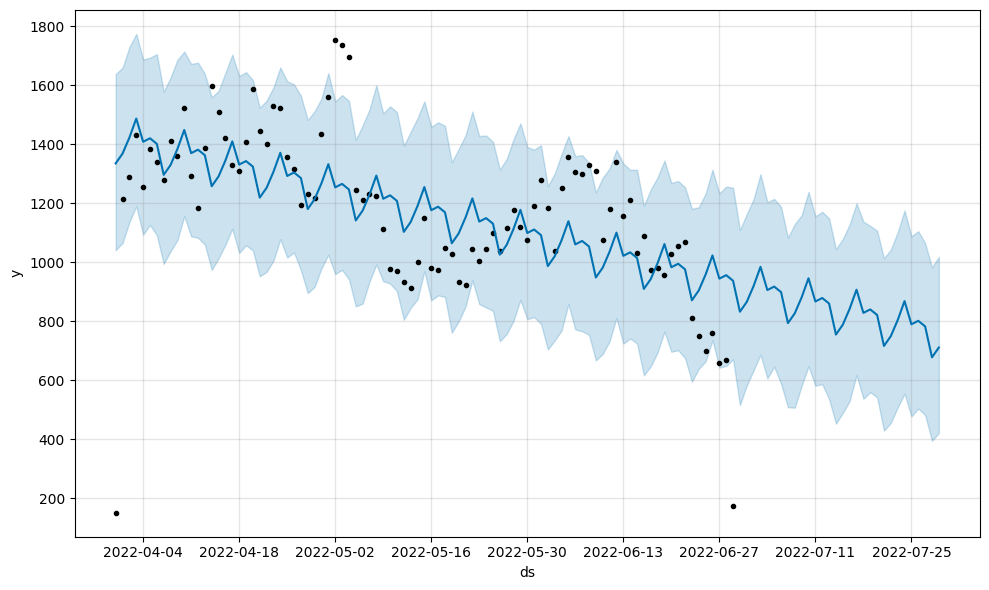

In [96]:
#genel tahmin grafiği
fig1=model.plot(forecast)

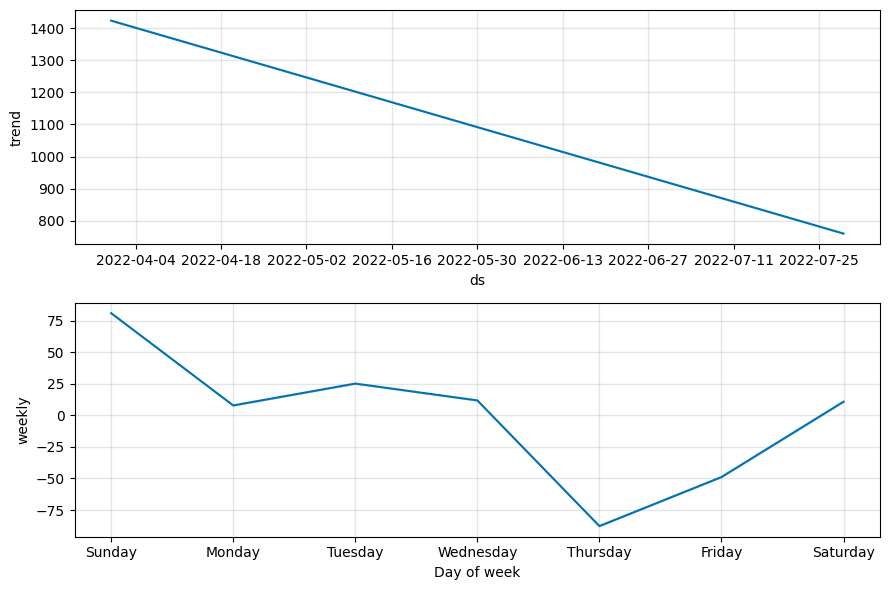

In [97]:
#bileşen analizi grafiği
fig2=model.plot_components(forecast)

In [98]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    model, 
    initial='60 days',   # İlk eğitim için 6 ay kullan
    period='15 days',     # Her 1 ayda bir yeni bir test penceresi aç
    horizon='30 days'     # 2 aylık tahmin başarısını ölç
)

df_p = performance_metrics(df_cv)

print(df_p.head())

  0%|          | 0/1 [00:00<?, ?it/s]

  horizon           mse        rmse         mae      mape     mdape     smape  \
0  3 days  39681.908174  199.203183  187.408820  0.154447  0.132097  0.169573   
1  4 days  35413.010391  188.183449  156.358122  0.129257  0.132097  0.142815   
2  5 days  37645.897912  194.025508  162.609443  0.135230  0.150016  0.149729   
3  6 days  29744.893162  172.467078  147.080760  0.113927  0.150016  0.123351   
4  7 days  53130.623112  230.500809  228.291783  0.174657  0.170433  0.191689   

   coverage  
0       1.0  
1       1.0  
2       1.0  
3       1.0  
4       1.0  


In [99]:
data.describe()


,Date,Qty,Amount
count,106573,106573.000000,106573.000000
mean,2022-05-11 19:47:13.201655296,1.003021,647.209612
min,2022-03-31 00:00:00,0.000000,0.000000
25%,2022-04-20 00:00:00,1.000000,448.000000
50%,2022-05-09 00:00:00,1.000000,599.000000
75%,2022-06-03 00:00:00,1.000000,788.000000
max,2022-06-29 00:00:00,15.000000,5584.000000
std,NaN,0.099685,283.972001


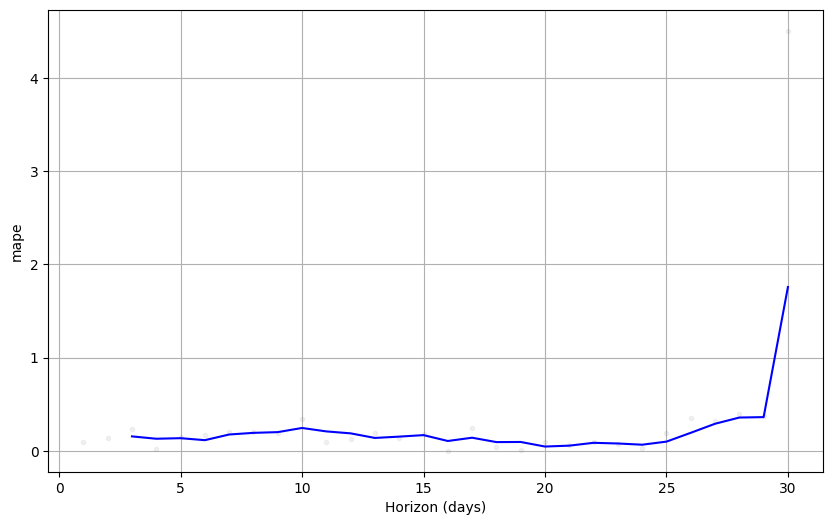

In [100]:
fig = plot_cross_validation_metric(df_cv, metric="mape")

In [101]:
#EDA
category_shares = data.groupby("Category")["Qty"].sum() / data['Qty'].sum()
print(category_shares)

Category
Blouse           0.007606
Bottom           0.003415
Dupatta          0.000028
Ethnic Dress     0.009271
Saree            0.001356
Set              0.387202
Top              0.084953
Western Dress    0.118883
kurta            0.387287
Name: Qty, dtype: float64


In [102]:
#Gelecek tahminlerini içeren forecast tablosu
future_forecast = forecast[["ds", "yhat"]].tail(30) 

for category, share in category_shares.items():
    future_forecast[category] = future_forecast["yhat"] * share

print(future_forecast.head())

           ds        yhat    Blouse    Bottom   Dupatta  Ethnic Dress  \
91 2022-06-30  832.742741  6.333503  2.843455  0.023371      7.720175   
92 2022-07-01  866.049708  6.586823  2.957184  0.024306      8.028956   
93 2022-07-02  920.202751  6.998689  3.142093  0.025825      8.530997   
94 2022-07-03  984.817353  7.490121  3.362724  0.027639      9.130025   
95 2022-07-04  906.201777  6.892203  3.094286  0.025432      8.401197   

       Saree         Set        Top  Western Dress       kurta  
91  1.129592  322.439983  70.743597      98.998969  322.510096  
92  1.174772  335.336521  73.573108     102.958601  335.409438  
93  1.248229  356.304709  78.173546     109.396478  356.382185  
94  1.335876  381.323638  83.662719     117.078057  381.406554  
95  1.229237  350.883498  76.984128     107.732000  350.959796  


In [103]:
lead_time = 5 
future_forecast["Reorder_Point"] = future_forecast["yhat"] * lead_time

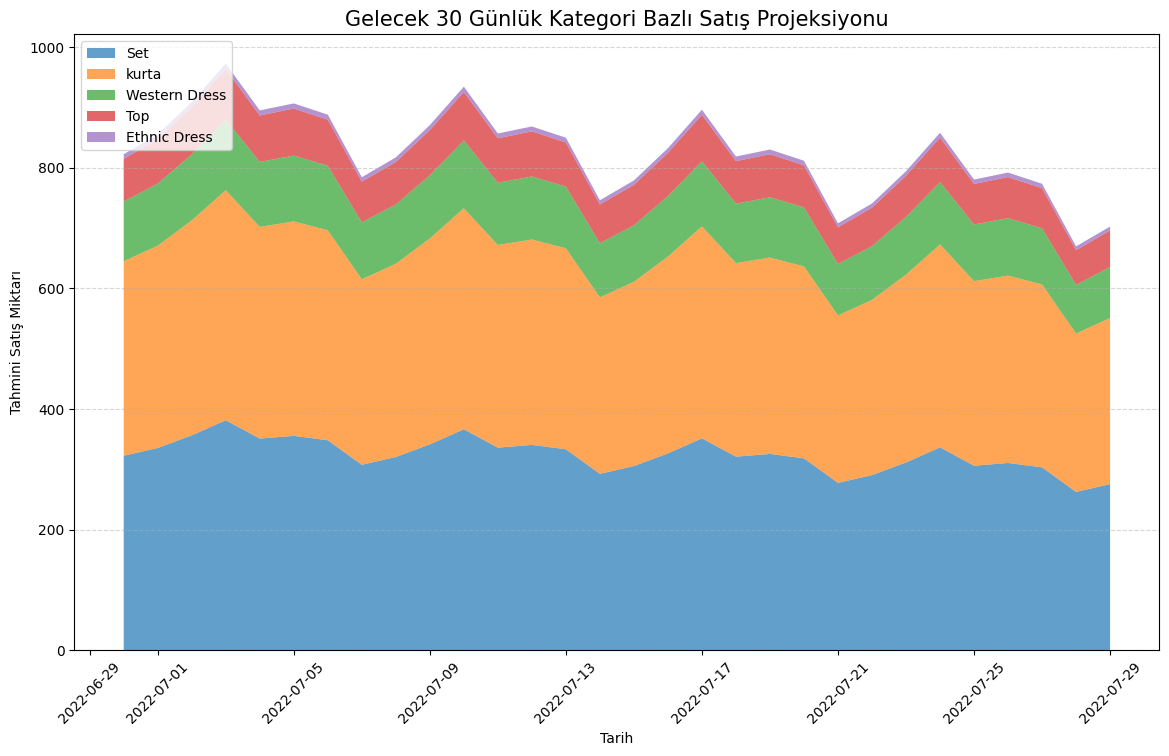

In [104]:
plt.figure(figsize=(14, 8))

categories_to_plot = ["Set", "kurta", "Western Dress", "Top", "Ethnic Dress"]

plt.stackplot(future_forecast["ds"], [future_forecast[c] for c in categories_to_plot], labels=categories_to_plot, alpha=0.7)
plt.title("Gelecek 30 Günlük Kategori Bazlı Satış Projeksiyonu", fontsize=15)
plt.xlabel("Tarih")
plt.ylabel("Tahmini Satış Miktarı")
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

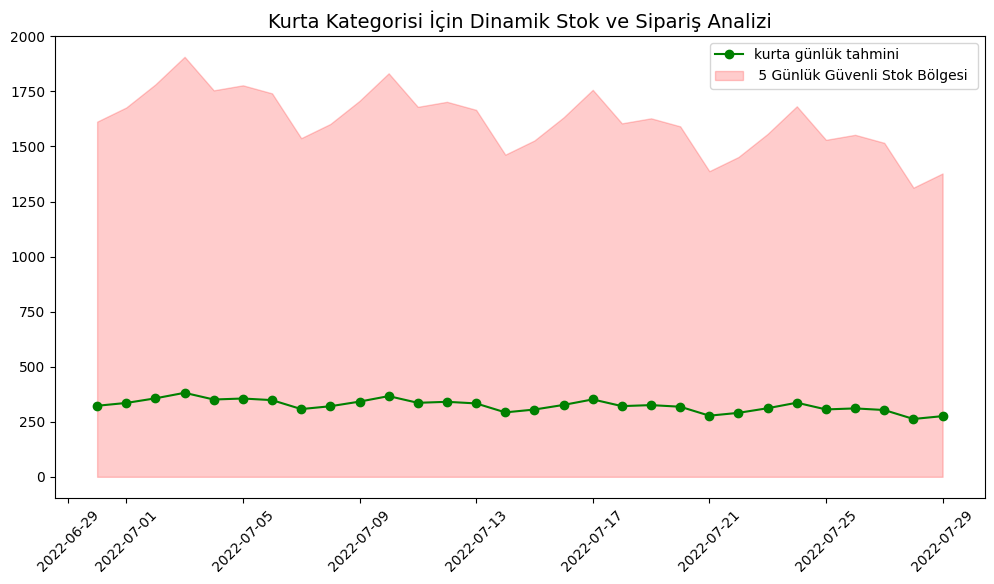

In [105]:
plt.figure(figsize=(12, 6))

plt.plot(future_forecast["ds"], future_forecast["kurta"], label="kurta günlük tahmini", color="green", marker="o")

plt.fill_between(future_forecast["ds"], 0, future_forecast["kurta"] * 5, alpha=0.2, color="red", label=" 5 Günlük Güvenli Stok Bölgesi ")

plt.title("Kurta Kategorisi İçin Dinamik Stok ve Sipariş Analizi", fontsize=14)
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [106]:
abc_analysis = category_shares.sort_values(ascending=False).to_frame()
abc_analysis.columns = ["Satış Payı"]
abc_analysis["Kümülatif Pay"] = abc_analysis["Satış Payı"].cumsum()

abc_analysis["Grup"] = abc_analysis["Kümülatif Pay"].apply(lambda x: 'A' if x <= 0.8 else ('B' if x <= 0.95 else 'C'))
print(abc_analysis)

               Satış Payı  Kümülatif Pay Grup
Category                                     
kurta            0.387287       0.387287    A
Set              0.387202       0.774489    A
Western Dress    0.118883       0.893372    B
Top              0.084953       0.978325    C
Ethnic Dress     0.009271       0.987595    C
Blouse           0.007606       0.995201    C
Bottom           0.003415       0.998615    C
Saree            0.001356       0.999972    C
Dupatta          0.000028       1.000000    C
